<p align="center">
  <img src="./yibo-quant.jpg" alt="课程封面" width="1300"/>
</p>


# 《和Yibo零基础学习量化金融》
## 从Python到AI量化交易实战 第一期
### 第四章：策略回测

---

## 本章你将学会

- ✅ 什么是 **回测**，以及它**不能**保证什么
- ✅ 如何用代码模拟 **买入 → 持仓 → 卖出**
- ✅ 怎么算 **策略收益** 和 **买入持有** 基准收益
- ✅ 画出「策略 vs 大盘」的 **净值曲线**（专业感拉满）
- ✅ 用大白话理解 **胜率** 和 **最大回撤**

**当前等级**  
🎮 **Lv.3 回测分析师**

**本章难度**  
⭐⭐⭐☆☆

**预计学习时间**  
30～45 分钟（需联网）

**前置知识**

- 完成 **第二章**（收益率、`pct_change`）
- 完成 **第三章**（双均线、`signal`）
- Python 基础、会用 Jupyter 从上到下运行单元格

---

上一章，你已经写出了 `if MA5 > MA20: 持有`。

但心里可能还会犯嘀咕：**这套规则，历史上到底赚没赚？**

这一章，我们就用 **回测** 来回答这个问题——让教程从「玩具演示」迈向 **有一点专业味的量化报告**。

> 第一期最后一章。通关后，你已经有能力向别人展示一张 **策略净值曲线**——这就是最好的「我入门了」的证明。

### 环境准备

老规矩，先跑这一格。缺库就在项目根目录：`pip install -r requirements.txt`

In [1]:
# ========== 环境准备 ==========
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

TICKER = 'AAPL'      # 策略交易哪只股票
BENCHMARK = 'SPY'    # 大盘对比用标普500 ETF
PERIOD = '2y'        # 回测样本长度

print('环境就绪 ✓')


环境就绪 ✓


---

### 4.1 什么是回测？

先讲一句大实话：

> **回测 = 用历史数据，假装你过去真的按规则交易了一遍。**

比如 2024～2025 年，你每天都按「MA5 > MA20 就持有」操作——回测会告诉你：如果当时真这么干了，账户曲线长什么样。

那很多人会问第二个问题：

**「如果一个策略过去有效，它未来是否可能有效？」**

答案是：**可能，但没人能打包票。**

- 过去有效，可能是因为 **碰巧** 适配了那段行情
- 市场会变，规则也可能 **失效**
- 回测的价值不是「预言未来」，而是 **在真金白银之前，先排雷、先建立直觉**

所以请记住这句话（比任何公式都重要）：

> **回测是体检，不是算命。**

---

### 4.2 如何模拟交易？

真实交易无非三件事，循环往复：

| 状态 | 你在做什么 |
|------|------------|
| **买入** | 用钱换股票，进入持仓 |
| **持仓** | 股票还在手里，涨跌跟着走 |
| **卖出** | 把股票换回钱，变成空仓 |

在代码里，我们用一个 **`position`（仓位）** 列来表示：

- `1` = 手里有股票（持仓）
- `0` = 空仓（现金）

第三章的双均线规则可以翻译成：

```text
今天收盘算信号 → 明天按信号交易（避免「偷看未来」）
MA5 > MA20  → 明天 position = 1
否则        → 明天 position = 0
```

下面我们把整条流水线跑通：下载数据 → 算均线 → 生成仓位。

In [2]:
# ========== 第1步：下载数据并算双均线 ==========
raw = yf.download(TICKER, period=PERIOD, progress=False, multi_level_index=False)
df = raw[['Close']].dropna().copy()
df.columns = ['Close']

df['MA5'] = df['Close'].rolling(5).mean()
df['MA20'] = df['Close'].rolling(20).mean()
df['signal'] = (df['MA5'] > df['MA20']).astype(int)  # 收盘算出的「理论信号」

# ========== 第2步：信号推迟一天，避免用未来数据 ==========
df['position'] = df['signal'].shift(1).fillna(0).astype(int)  # 今天实际仓位

# ========== 第3步：标记买入、卖出日 ==========
df['position_change'] = df['position'].diff().fillna(0)  # 仓位变化：0→1买，1→0卖
df['action'] = ''
df.loc[df['position_change'] > 0, 'action'] = '买入'
df.loc[df['position_change'] < 0, 'action'] = '卖出'

trades = df[df['action'] != '']
print(f'标的 {TICKER}，共 {len(df)} 个交易日')
print(f'模拟交易：买入 { (df["action"]=="买入").sum() } 次，卖出 { (df["action"]=="卖出").sum() } 次')
print('\n最近几次调仓：')
display(trades[['Close', 'MA5', 'MA20', 'position', 'action']].tail(6))


标的 AAPL，共 501 个交易日
模拟交易：买入 16 次，卖出 15 次

最近几次调仓：


,Close,MA5,MA20,position,action
Date,,,,,
2025-12-18,271.685242,273.697491,276.629045,0,卖出
2026-02-03,268.980286,262.250778,257.232587,1,买入
2026-02-20,264.336456,261.592987,264.651840,0,卖出
2026-02-26,272.698761,269.767462,268.063290,1,买入
2026-03-04,262.278351,265.379498,268.008755,0,卖出
2026-04-07,253.266663,255.304776,252.928470,1,买入


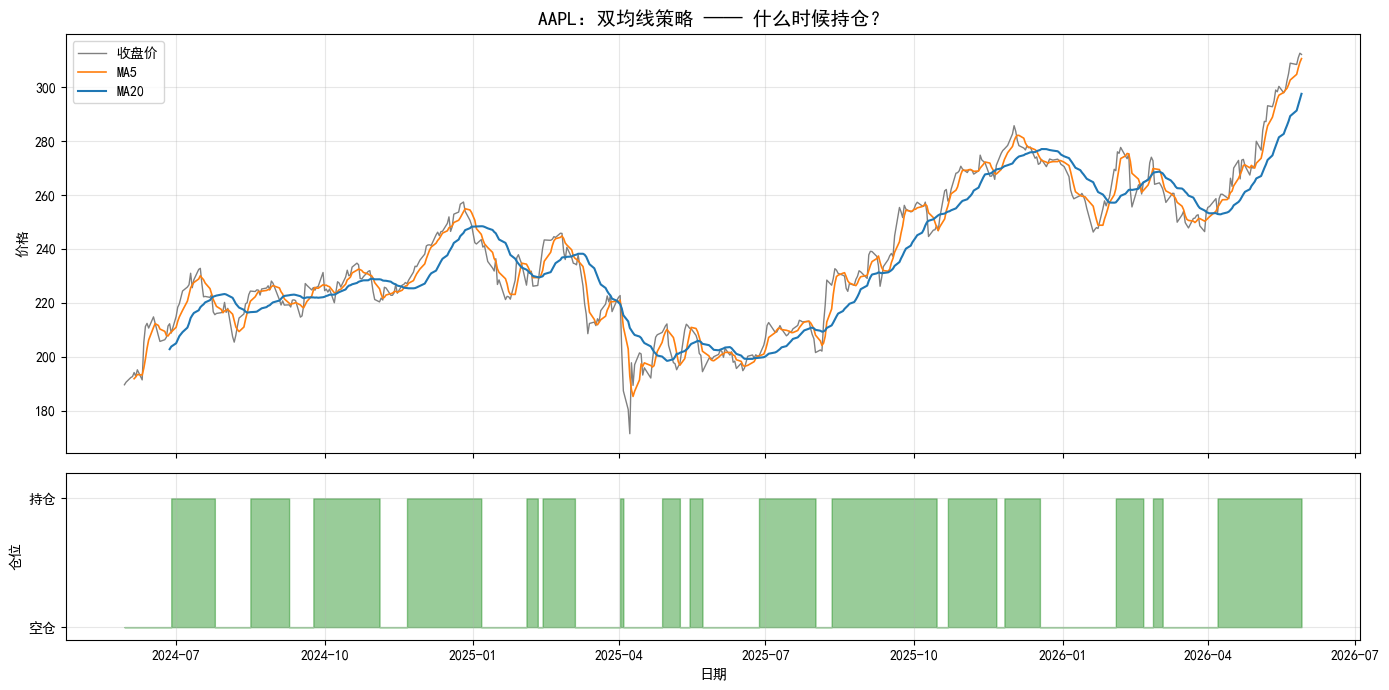

绿色区域 = 持仓（买入后、卖出前）| 空白 = 空仓


In [3]:
# ========== 价格+均线 + 持仓时间条 ==========
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                         gridspec_kw={'height_ratios': [2.5, 1]})

axes[0].plot(df.index, df['Close'], color='gray', linewidth=1, label='收盘价')
axes[0].plot(df.index, df['MA5'], color='tab:orange', linewidth=1.2, label='MA5')
axes[0].plot(df.index, df['MA20'], color='tab:blue', linewidth=1.5, label='MA20')
axes[0].set_ylabel('价格')
axes[0].set_title(f'{TICKER}：双均线策略 —— 什么时候持仓？', fontsize=14)
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

axes[1].fill_between(df.index, 0, df['position'], step='post', alpha=0.4, color='green')
axes[1].set_ylim(-0.1, 1.2)
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['空仓', '持仓'])
axes[1].set_xlabel('日期')
axes[1].set_ylabel('仓位')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('绿色区域 = 持仓（买入后、卖出前）| 空白 = 空仓')


---

### 4.3 策略收益率

还记得第二章吗？

如果股票 **昨天 100 元，今天 110 元** —— 我们到底赚了多少？

答案是：**日收益率约 +10%**（用 `pct_change()` 算）。

现在多了一步：

- **持仓那天**：股票的涨跌，算到你头上 → `策略日收益 = 仓位 × 日收益率`
- **空仓那天**：你没买股票，涨跌和你无关 → 策略日收益 = 0

再把每天的收益 **连乘** 起来，就得到 **累计收益曲线**（也叫净值曲线）。

同时我们会算一条 **基准** 曲线做对照：

| 曲线 | 含义 |
|------|------|
| **策略净值** | 按双均线规则买卖后的结果 |
| **买入持有（同标的）** | 第一天全仓买入，一直不动 |
| **买入持有（SPY 大盘）** | 同期持有标普500 ETF，看「市场本身」涨了多少 |

In [4]:
# ========== 算日收益率 ==========
df['ret'] = df['Close'].pct_change().fillna(0)  # 股票本身每天涨跌

# ========== 策略收益：只有持仓日才吃到涨跌 ==========
df['strategy_ret'] = df['position'] * df['ret']

# ========== 基准1：买入持有（一直满仓）==========
df['buyhold_ret'] = df['ret']

# ========== 基准2：同期持有大盘 SPY ==========
spy = yf.download(BENCHMARK, period=PERIOD, progress=False, multi_level_index=False)[['Close']]
spy.columns = ['SPY_Close']
df = df.join(spy, how='inner')  # 按日期对齐，只保留两边都有数据的行
df['market_ret'] = df['SPY_Close'].pct_change().fillna(0)

# ========== 累计净值：从 1 元钱出发连乘 ==========
df['nav_strategy'] = (1 + df['strategy_ret']).cumprod()
df['nav_buyhold'] = (1 + df['buyhold_ret']).cumprod()
df['nav_market'] = (1 + df['market_ret']).cumprod()

total_strategy = df['nav_strategy'].iloc[-1] - 1
total_buyhold = df['nav_buyhold'].iloc[-1] - 1
total_market = df['nav_market'].iloc[-1] - 1

print('=== 样本期累计收益（不含手续费，仅供学习）===')
print(f'  双均线策略 ({TICKER}): {total_strategy:+.2%}')
print(f'  买入持有 ({TICKER}):     {total_buyhold:+.2%}')
print(f'  买入持有 ({BENCHMARK} 大盘): {total_market:+.2%}')


=== 样本期累计收益（不含手续费，仅供学习）===
  双均线策略 (AAPL): +2.35%
  买入持有 (AAPL):     +64.55%
  买入持有 (SPY 大盘): +48.27%


---

### 4.4 回测结果可视化（本章高潮）

数字表格不够直观。

一张 **策略 vs 基准** 的净值图，是量化报告里最常见、也最能建立「专业感」的图之一。

看图时只问自己三件事：

1. 策略曲线 **整体往上** 还是往下？
2. 策略有没有 **跑赢** 买入持有？有没有 **跑输** 大盘？
3. 中间有没有 **大坑**（后面 4.6 会讲回撤）？

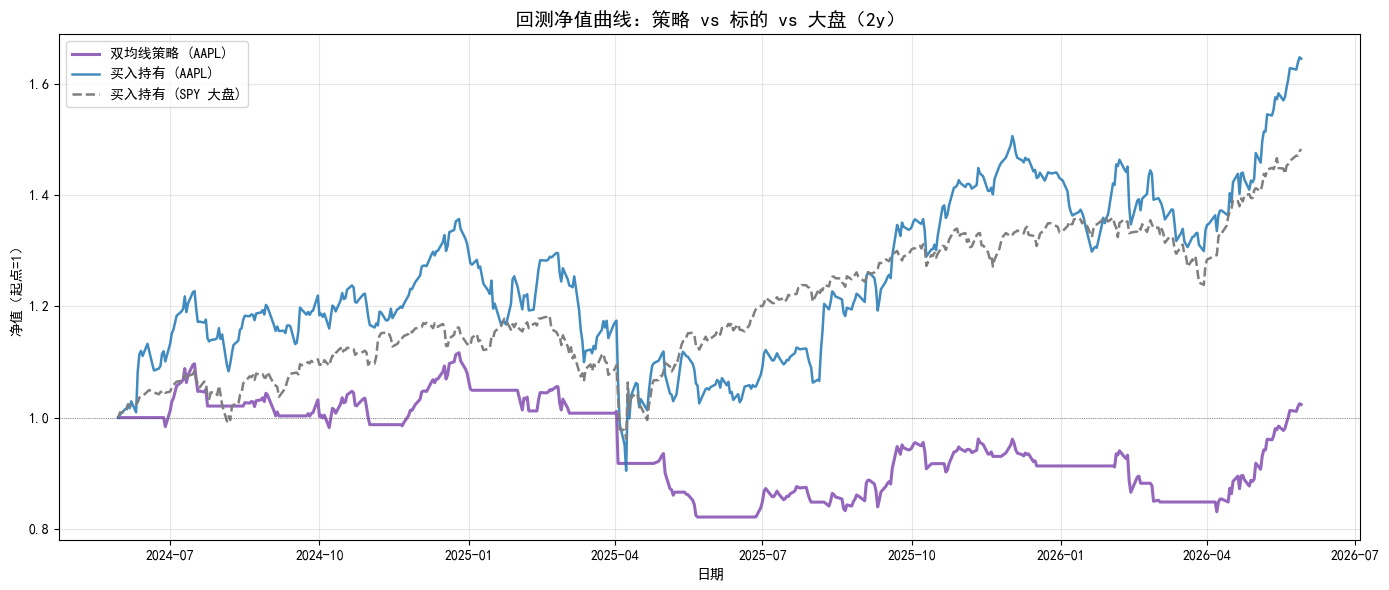

In [5]:
# ========== 三条净值曲线对比（回测高潮图）==========
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df['nav_strategy'], linewidth=2.2, color='tab:purple',
        label=f'双均线策略 ({TICKER})')
ax.plot(df.index, df['nav_buyhold'], linewidth=1.8, color='tab:blue', alpha=0.85,
        label=f'买入持有 ({TICKER})')
ax.plot(df.index, df['nav_market'], linewidth=1.8, color='tab:gray', linestyle='--',
        label=f'买入持有 ({BENCHMARK} 大盘)')

ax.axhline(1.0, color='black', linewidth=0.6, linestyle=':', alpha=0.5)
ax.set_title(f'回测净值曲线：策略 vs 标的 vs 大盘（{PERIOD}）', fontsize=14)
ax.set_xlabel('日期')
ax.set_ylabel('净值（起点=1）')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


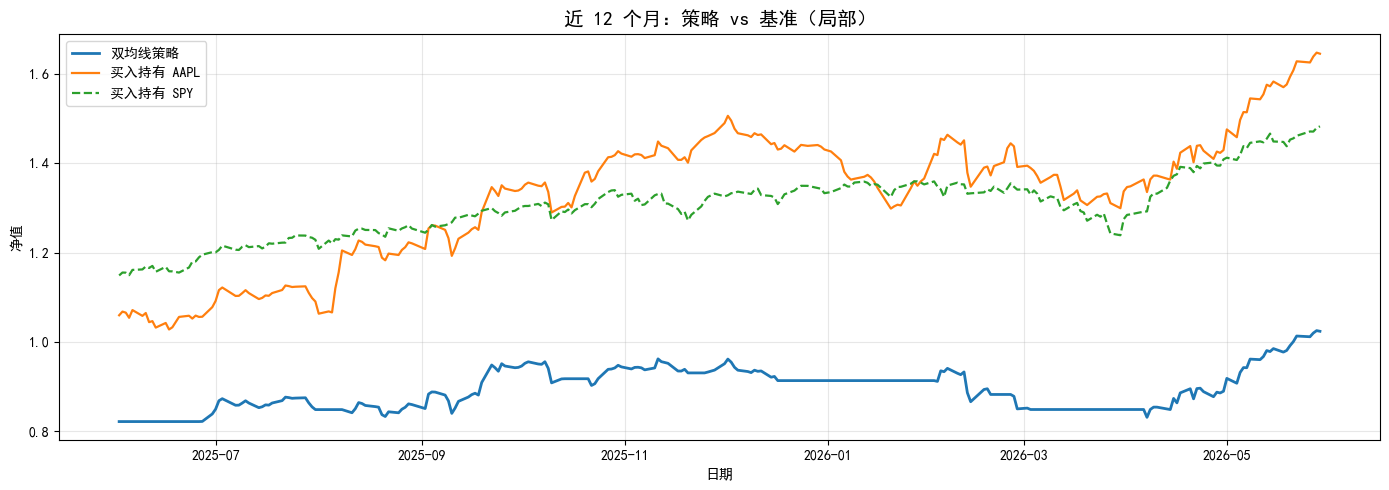

In [6]:
# ========== 近12个月局部放大 ==========
recent = df.last('12M') if len(df) > 200 else df.tail(200)

plt.figure(figsize=(14, 5))
plt.plot(recent.index, recent['nav_strategy'], linewidth=2, label='双均线策略')
plt.plot(recent.index, recent['nav_buyhold'], linewidth=1.6, label=f'买入持有 {TICKER}')
plt.plot(recent.index, recent['nav_market'], linewidth=1.6, linestyle='--', label=f'买入持有 {BENCHMARK}')
plt.title('近 12 个月：策略 vs 基准（局部）', fontsize=14)
plt.xlabel('日期')
plt.ylabel('净值')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---

### 4.5 什么是胜率？

别被名词吓到。**胜率** 就是一句人话：

> **你完整做完的每一笔「买进→卖出」，赚的多还是亏的多？**

我们这里用最朴素的方式数：

- 每次 **买入** 记一个买入价
- 到下一次 **卖出**，看卖出价是否高于买入价
- **赢** = 赚了，`输` = 亏了

胜率 = 赢的次数 ÷（赢 + 输）

> 注意：这不是「每一天涨跌的胜率」，而是 **一轮轮交易** 的胜率——对初学者更直观。

In [7]:
# ========== 统计胜率：一轮「买入→卖出」算一局 ==========
wins, losses = 0, 0       # 赢、输次数
entry_price = None        # 记住买入价
records = []              # 存每轮结果

for date, row in df.iterrows():  # 按天遍历整张表
    if row['action'] == '买入':
        entry_price = row['Close']   # 记录买入当天的收盘价
    elif row['action'] == '卖出' and entry_price is not None:
        pnl = row['Close'] / entry_price - 1   # 本轮收益率
        if pnl > 0:
            wins += 1
            outcome = '赢'
        else:
            losses += 1
            outcome = '输'
        records.append({
            '卖出日': date.strftime('%Y-%m-%d'),
            '买入价': round(entry_price, 2),
            '卖出价': round(row['Close'], 2),
            '本轮收益': f'{pnl:+.2%}',
            '结果': outcome,
        })
        entry_price = None   # 本轮结束，清空买入价

total_rounds = wins + losses
win_rate = wins / total_rounds if total_rounds > 0 else np.nan

print(f'完整交易回合：{total_rounds} 轮')
print(f'  赢：{wins} 次')
print(f'  输：{losses} 次')
print(f'  胜率：{win_rate:.1%}' if total_rounds > 0 else '  暂无完整买卖回合')

if records:
    display(pd.DataFrame(records).tail(8))


完整交易回合：15 轮
  赢：5 次
  输：10 次
  胜率：33.3%


,卖出日,买入价,卖出价,本轮收益,结果
7,2025-05-09,209.04,197.49,-5.52%,输
8,2025-05-23,210.61,194.50,-7.65%,输
9,2025-08-01,200.29,201.58,+0.65%,赢
10,2025-10-15,226.54,248.64,+9.75%,赢
11,2025-11-21,257.72,270.99,+5.15%,赢
12,2025-12-18,277.04,271.69,-1.93%,输
13,2026-02-20,268.98,264.34,-1.73%,输
14,2026-03-04,272.70,262.28,-3.82%,输


---

### 4.6 什么是最大回撤？（初步认识）

赚钱很重要，但老手一定会问：**「最惨的时候亏过多深？」**

想象你的净值曲线是一座山：

- 你先爬到一个 **山顶**（历史最高点）
- 然后一路往下走，掉到某个 **谷底**
- 从山顶到谷底，跌了多少比例 —— 这一段就叫 **回撤**
- 整段样本里 **最深的那一次**，叫 **最大回撤（Max Drawdown）**

它不代表「一定会亏这么多」，而是告诉你：

> **这套策略历史上，曾经让你最难受的时候有多难受。**

本章 **不深挖** 公式和优化；你只要记住：**回撤越大，心理压力通常越大** —— 风险真实存在。

=== 最大回撤（样本期内最深一次「从山顶滑落」）===
  双均线策略: -26.46%
  买入持有 (AAPL): -33.36%


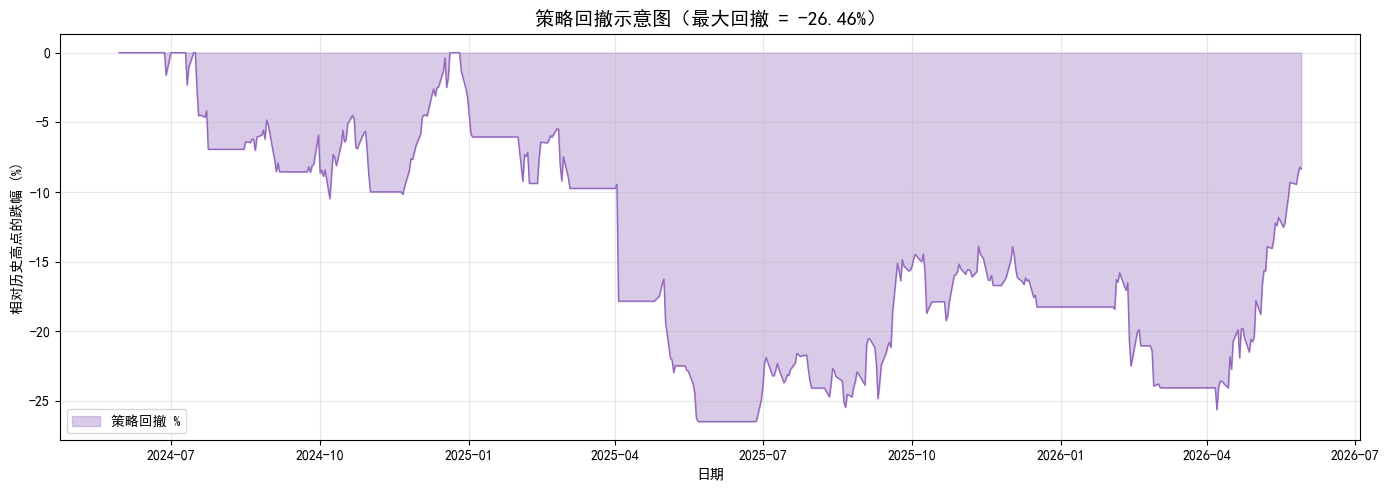

In [8]:
# ========== 最大回撤：从历史最高点最多跌了多少 ==========
def max_drawdown(nav_series):
    """输入净值序列，返回 (最大回撤比例, 每日回撤序列)。"""
    peak = nav_series.cummax()           # 到每一天为止的历史最高净值
    drawdown = nav_series / peak - 1     # 当前净值相对峰值的跌幅
    return drawdown.min(), drawdown

mdd_strategy, dd_strategy = max_drawdown(df['nav_strategy'])
mdd_buyhold, dd_buyhold = max_drawdown(df['nav_buyhold'])

print('=== 最大回撤（样本期内最深一次「从山顶滑落」）===')
print(f'  双均线策略: {mdd_strategy:.2%}')
print(f'  买入持有 ({TICKER}): {mdd_buyhold:.2%}')

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(df.index, dd_strategy * 100, 0, alpha=0.35, color='tab:purple', label='策略回撤 %')
ax.plot(df.index, dd_strategy * 100, color='tab:purple', linewidth=1)
ax.set_title(f'策略回撤示意图（最大回撤 = {mdd_strategy:.2%}）', fontsize=14)
ax.set_xlabel('日期')
ax.set_ylabel('相对历史高点的跌幅 (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---

## 🎯 挑战任务（第四章通关 · 第一期毕业）

1. 把 `TICKER` 改成 **`'NVDA'`**，截一张 **策略 vs 大盘** 净值图，写一句话：跑赢还是跑输？  
2. 对比 `PERIOD='1y'` 和 `'5y'`：最大回撤哪个更深？你更能接受哪种？  
3. **毕业题**：用三句话向朋友解释「回测是什么」——发不出去就说明还没懂，再读一遍 4.1。

---

## 本章总结

- **回测** 用历史假装交易一遍；**过去好 ≠ 未来一定好**。  
- 模拟交易 = `position` 在 **买入 / 持仓 / 卖出** 之间切换；记得 `shift(1)`。  
- **策略收益** = 持仓日的涨跌累乘；要和 **买入持有、大盘** 对照着看。  
- **净值曲线** 是专业报告的门面。  
- **胜率** 数的是完整回合赢几次；**最大回撤** 提醒你风险有多深。

---

## 第一期完结 🎉

恭喜你走完 **量化启蒙四讲**：

1. 什么是量化金融  
2. 第一个数据分析实验  
3. 移动平均线策略  
4. 策略回测  

你已经有了一条完整链路：**数据 → 规则 → 回测 → 看图说话**。

后面阶段我们会继续加深（因子、风险指标、更复杂的策略），但请记住本课程的原则：

> **不追求讲完所有知识，只追求让更多人真正入门。**